
# Transport convectif de quantité de mouvement — trois objectifs

### Méso-NH RCE `large300` · décomposition, stratification spatiale et fermeture du flux de Reynolds


**Acquis des notebooks précédents** (rappelés, non re-démontrés). La décomposition exacte sur
trois catégories (up / dn / env), de seuil $w_s=\max(w_0,C\,\sigma_w)$,

$$\rho_0\overline{u'w'}
=\underbrace{\sum_{k}\rho_0\,\sigma_k(\bar u_k-\bar u)(\bar w_k-\bar w)}_{T_1\ \text{(organisé, « flux de masse »)}}
+\underbrace{\sum_{k}\rho_0\,\sigma_k\,\big\langle(u-\bar u_k)(w-\bar w_k)\big\rangle_k}_{T_2\ \text{(covariance interne, sous-maille)}}$$

ferme le budget au zéro machine, avec en médiane $T_1\!\approx\!56\,\%$ et $T_2\!\approx\!44\,\%$.
On a montré que $T_2$ est un terme **d'amplitude** ($\langle u'w'\rangle_{up}=r_0\,\sigma_u\sigma_w$,
corrélation $r_0$ plate, amplitude variable) et **non diffusif** : aucune fermeture *down-gradient*
ne le capture. C'est précisément ce terme que les objectifs ① et ② cherchent à apprivoiser, et que
l'objectif ③ cherche à fermer proprement.


## 0 — Setup commun (pipeline `large300`)

Conventions **identiques** à tes notebooks : fichiers 3D séparés par variable, altitude reprise du
1D, état stationnaire = dernier tiers, $\rho_0(z)$ via température virtuelle, lecture
**niveau par niveau** pour la RAM. Une seule fonction de classification `classify` pour tout le
notebook, pour que ① ② ③ restent strictement comparables.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25})

Rd, Rv = 287.05, 461.5
EPSILON = Rd / Rv
DIR_3D, DIR_2D, DIR_1D = '3D', '2D', '1D'
def path3d(v): return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{v}.nc')
BLOC = 2
DX_DEFAULT = 1000.0       # m (forcé si les coords x sont des indices entiers)
print('Setup prêt.')

Setup prêt.


In [2]:

# --- dimensions + altitude ---
_ds = xr.open_dataset(path3d('ua')); _da = _ds['ua']
dim_t, dim_z, dim_y, dim_x = _da.dims[:4]
n_t, n_z = _da.sizes[dim_t], _da.sizes[dim_z]
n_y, n_x = _da.sizes[dim_y], _da.sizes[dim_x]
# résolution horizontale
_xv = _da[dim_x].values
dx = float(np.mean(np.diff(_xv))) if _xv.size > 1 else DX_DEFAULT
if abs(dx) <= 1.5:        # coords = indices -> vraie résolution
    dx = DX_DEFAULT
_ds.close(); del _ds, _da; gc.collect()

_ds1 = xr.open_dataset(path1d('ua_avg'))
alt  = _ds1.altitude.values.astype(float).copy()
_ds1.close(); del _ds1; gc.collect()

x = np.arange(n_x, dtype=float) * dx     # axe x en mètres
t_stat   = int(2*n_t/3)                   # dernier tiers = stationnaire
idx_stat = slice(t_stat, None)
n_stat   = n_t - t_stat
print(f'{n_t} t × {n_z} z × {n_y} y × {n_x} x')
print(f'altitude {alt[0]:.0f}–{alt[-1]:.0f} m | dx={dx:.0f} m (domaine {n_x*dx/1000:.0f} km) | t_stat={t_stat}')

100 t × 74 z × 128 y × 2000 x
altitude 0–32500 m | dx=1000 m (domaine 2000 km) | t_stat=66


In [3]:

# --- masques humide/sec via PRW ---
ds_prw  = xr.open_dataset(path2d('prw'))
prw_all = ds_prw['prw'].load(); ds_prw.close()
prw_mean  = prw_all.isel({dim_t: idx_stat}).mean(dim=dim_t)
PRW_SEUIL = float(np.median(prw_all.values.ravel()))
mh = (prw_mean.values > PRW_SEUIL); ms = ~mh    # masques 2D (y,x)
f_h, f_s = mh.mean(), ms.mean()
del prw_all; gc.collect()
print(f'Humide {f_h*100:.1f}%   Sec {f_s*100:.1f}%  (seuil PRW={PRW_SEUIL:.1f} kg/m²)')

Humide 42.3%   Sec 57.7%  (seuil PRW=30.4 kg/m²)


In [4]:

# --- densité de référence rho0(z) via température virtuelle ---
rho0_sum = np.zeros(n_z); n_rho = 0
ds_ta = xr.open_dataset(path3d('ta')); ds_pa = xr.open_dataset(path3d('pa')); ds_hus = xr.open_dataset(path3d('hus'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    T  = ds_ta['ta'].isel(sl).values; p = ds_pa['pa'].isel(sl).values; qv = ds_hus['hus'].isel(sl).values
    Tv = T*(1+qv/EPSILON)/(1+qv); rho = p/(Rd*Tv)
    rho0_sum += rho.mean(axis=(0,2,3))*(t1-t0); n_rho += (t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); del ds_ta,ds_pa,ds_hus; gc.collect()
rho0 = rho0_sum/n_rho
print(f'rho0 surface {rho0[0]:.3f}  ~10km {rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m³')

rho0 surface 1.183  ~10km 0.410 kg/m³


In [5]:

# --- outils partagés : classification up/dn/env, bande tropo, scores ---
W0_MIN_DEFAULT = 0.001

def classify(w, C, w0=W0_MIN_DEFAULT):
    # Partition d'un vecteur w (1D) en up/dn/env via w_s = max(w0, C*std(w)).
    ws  = max(w0, C*w.std())
    return ws, (w > ws), (w < -ws), (np.abs(w) <= ws)

def band(z0=2000, z1=18000):
    # Tranche d'indices de la troposphère libre (écarte couche de surface et jet).
    return slice(np.searchsorted(alt, z0), np.searchsorted(alt, z1))

def nse(truth, pred, s):
    # Nash–Sutcliffe efficiency sur la tranche s (1 = parfait, 0 = vaut la moyenne).
    a, b = truth[s], pred[s]; ok = np.isfinite(a) & np.isfinite(b)
    return 1 - np.nansum((a[ok]-b[ok])**2) / np.nansum((a[ok]-np.nanmean(a[ok]))**2)

def tendance(flux):
    # Force de Reynolds : -1/rho0 d(flux)/dz, où flux = rho0<phi'w'>.
    return -np.gradient(flux, alt) / rho0

print('classify / band / nse / tendance  -> OK')

classify / band / nse / tendance  -> OK



---
# ① Stratification spatiale de la paramétrisation $\alpha(z),\beta(z)$

**Le problème.** La fermeture linéaire à deux termes

$$y(z,t)\;\equiv\;-\frac{1}{\rho_0}\partial_z\!\big(\rho_0\overline{u'w'}\big)
\;=\;\alpha(z)\,\rho_0\bar u \;+\;\beta(z)\,\partial_z(\rho_0\bar u)
\;\equiv\;\alpha(z)\,x_1+\beta(z)\,x_2$$

s'ajuste, à chaque niveau $z$, par régression des moindres carrés sur **la dimension temporelle**
(les $\sim n_{stat}$ pas stationnaires fournissent les échantillons). Tu l'as fait sur les régions
humide / sèche. **La question ① :** existe-t-il un *découpage plus fin* du domaine — en zones de
20–30–50 km, guidées par le cisaillement et l'humidité — qui donne des $\alpha,\beta$ plus
**exploitables** ?

**Ce que « exploitable » veut dire, concrètement.** Un couple $(\alpha,\beta)$ est exploitable si :
1. il **reconstruit** bien la tendance dans sa zone (NSE élevé) ;
2. il est **stable dans le temps** (faible dispersion de $\alpha,\beta$ d'un instant à l'autre :
   on ne veut pas un ajustement qui change de signe à chaque pas) ;
3. il n'est pas bâti sur **une moyenne quasi nulle** : si $\langle y\rangle\approx0$ dans une zone,
   le fit ajuste du bruit et le moindre $\alpha$ explose. On mesure ça par le **rapport
   signal/bruit** de $y$ dans la zone.

**Stratégie.** On définit un **indicateur de zone** par colonne $(y,x)$ : croisement
(humide/sec) × (fort/faible cisaillement de basse-moyenne troposphère). Le cisaillement est
calculé sur le champ moyen, exactement l'information « lignes de courant / gros cisaillement » de
la consigne. On compare alors trois découpages : **(D0)** domaine entier, **(D1)** humide/sec
(ton existant), **(D2)** humide/sec × cisaillement (4 zones). Pour chacun on quantifie les trois
critères d'exploitabilité.


## 1.1 — Carte de cisaillement et définition des zones

Le **cisaillement de référence** d'une colonne est l'amplitude moyenne de $\partial_z u$ dans la
couche 1–6 km (là où le flux de masse convectif et le CMT sont les plus actifs). On le calcule
par colonne, sur l'état stationnaire moyenné en temps, puis on le seuille à sa médiane *au sein de
chaque régime d'humidité* (pour que chaque sous-zone reste de taille raisonnable, ~20–50 % du
domaine). On obtient quatre zones : humide×fort, humide×faible, sec×fort, sec×faible.

In [6]:

# ---------------------------------------------------------------------------
# Carte de cisaillement S(y,x) = <|du/dz|>_{1-6 km}, moyennée sur le temps stat.
# Lecture niveau par niveau ; on n'accumule que les niveaux de la couche utile.
# ---------------------------------------------------------------------------
Z_SHEAR_LO, Z_SHEAR_HI = 1000.0, 6000.0
iz_layer = np.where((alt >= Z_SHEAR_LO) & (alt <= Z_SHEAR_HI))[0]

# u moyenné en temps à chaque niveau de la couche -> (nlev, ny, nx)
u_layer = np.zeros((iz_layer.size, n_y, n_x))
ds_u = xr.open_dataset(path3d('ua'))
for k, iz in enumerate(iz_layer):
    u_layer[k] = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).mean(dim=dim_t).values
ds_u.close(); del ds_u; gc.collect()

# du/dz par colonne (gradient vertical sur la couche), puis amplitude moyenne
dudz = np.gradient(u_layer, alt[iz_layer], axis=0)      # (nlev, ny, nx)
shear_map = np.abs(dudz).mean(axis=0)                    # (ny, nx)  [s^-1]
del u_layer, dudz; gc.collect()

# Seuils de cisaillement DANS chaque régime d'humidité (médiane interne)
sh_h = np.median(shear_map[mh]); sh_s = np.median(shear_map[ms])
print(f'cisaillement médian : humide {sh_h:.2e} s⁻¹   sec {sh_s:.2e} s⁻¹')

# 4 zones : (humide/sec) × (fort/faible cisaillement)
zone = {
    'h_fort' : mh & (shear_map >  sh_h),
    'h_faible': mh & (shear_map <= sh_h),
    's_fort' : ms & (shear_map >  sh_s),
    's_faible': ms & (shear_map <= sh_s),
}
for k, m in zone.items():
    print(f'  zone {k:9s}: {m.mean()*100:5.1f}% du domaine')

cisaillement médian : humide 1.07e-03 s⁻¹   sec 1.12e-03 s⁻¹
  zone h_fort   :  21.1% du domaine
  zone h_faible :  21.1% du domaine
  zone s_fort   :  28.9% du domaine
  zone s_faible :  28.9% du domaine


/tmp/ipykernel_57487/670825222.py:4: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im0 = ax[0].pcolormesh(prw_mean.values, cmap='Blues'); ax[0].set_title('PRW moyen', fontweight='bold')
/tmp/ipykernel_57487/670825222.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im1 = ax[1].pcolormesh(shear_map*1e3, cmap='magma'); ax[1].set_title(r'Cisaillement $\langle|\partial_z u|\rangle_{1-6km}$', fontweight='bold')
/tmp/ipykernel_57487/670825222.py:14: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im2 = ax[2].pcolormesh(zmap, cmap=cmap4, vmin=-.5, vmax=3.5)


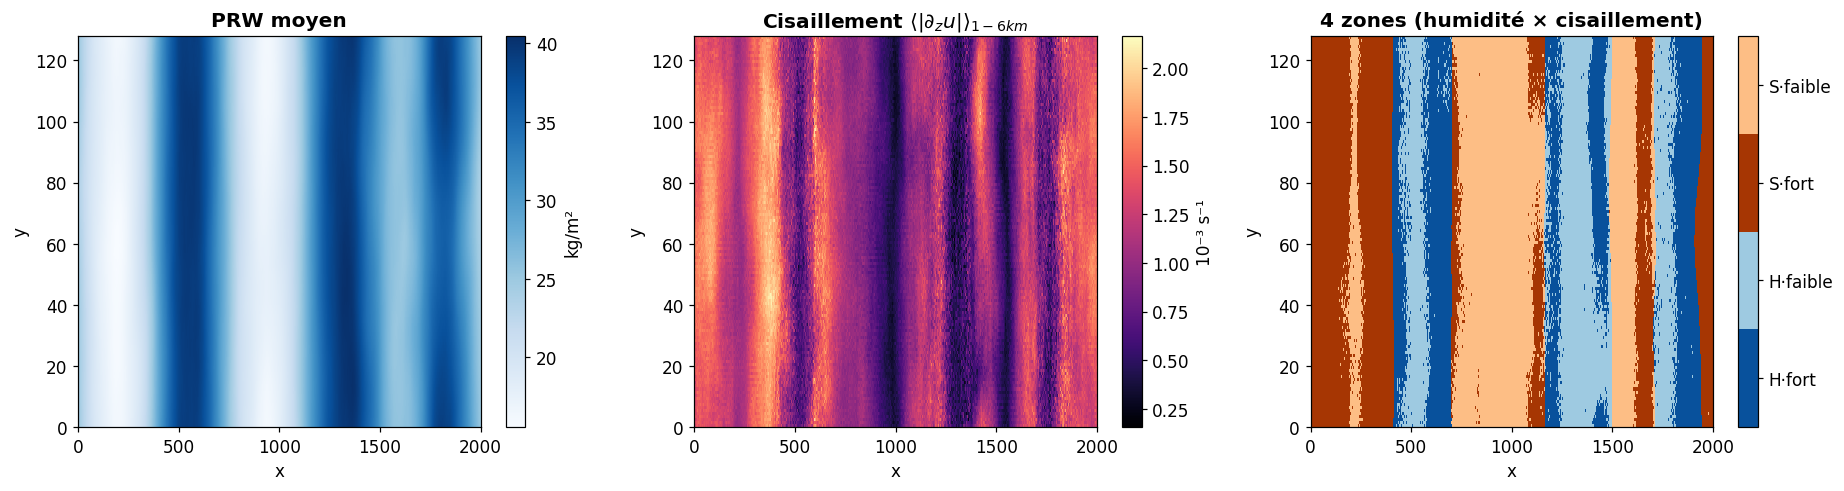

In [7]:

# --- visualisation des cartes : PRW, cisaillement, et les 4 zones ---
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

im0 = ax[0].pcolormesh(prw_mean.values, cmap='Blues'); ax[0].set_title('PRW moyen', fontweight='bold')
fig.colorbar(im0, ax=ax[0], label='kg/m²')

im1 = ax[1].pcolormesh(shear_map*1e3, cmap='magma'); ax[1].set_title(r'Cisaillement $\langle|\partial_z u|\rangle_{1-6km}$', fontweight='bold')
fig.colorbar(im1, ax=ax[1], label='10⁻³ s⁻¹')

zmap = np.full((n_y, n_x), np.nan)
for i, k in enumerate(('h_fort','h_faible','s_fort','s_faible')):
    zmap[zone[k]] = i
cmap4 = mcolors.ListedColormap(['#08519c', '#9ecae1', '#a63603', '#fdbe85'])
im2 = ax[2].pcolormesh(zmap, cmap=cmap4, vmin=-.5, vmax=3.5)
cb = fig.colorbar(im2, ax=ax[2], ticks=[0,1,2,3]); cb.ax.set_yticklabels(['H·fort','H·faible','S·fort','S·faible'])
ax[2].set_title('4 zones (humidité × cisaillement)', fontweight='bold')
for a in ax: a.set_xlabel('x'); a.set_ylabel('y')
plt.tight_layout(); plt.show()


## 1.2 — Régression $\alpha(z),\beta(z)$ par zone (équations normales $2\times2$)

À chaque niveau $z$ et pour chaque zone, on empile les $n_{stat}$ instants stationnaires et on
résout les **moindres carrés** $y=\alpha x_1+\beta x_2$ par les équations normales (système
$2\times2$, solution de Cramer). On garde aussi, à chaque niveau, la valeur **par instant** de
$(\alpha,\beta)$ — obtenue en résolvant le même système avec un seul échantillon spatialement
moyenné — pour mesurer la **dispersion temporelle** (critère d'exploitabilité n°2).

- $x_1=\rho_0\bar u_{\text{zone}}(z,t)$  (moyenne *dans la zone*),
- $x_2=\partial_z(\rho_0\bar u_{\text{zone}})(z,t)$,
- $y=-\rho_0^{-1}\partial_z(\rho_0\langle u'w'\rangle_{\text{zone}})(z,t)$, l'anomalie $u'w'$ étant
  prise **dans la zone** (convention intra-zone, cohérente avec le but : une fermeture locale).

In [8]:

# ---------------------------------------------------------------------------
# alpha(z), beta(z) par zone via régression temporelle (équations normales 2x2)
#   Pour chaque zone et chaque niveau interne iz (besoin de iz-1, iz+1 pour d/dz) :
#     on accumule sur t : x1=rho0*<u>_zone, x2=d(rho0<u>)/dz, y=-1/rho0 d(rho0<u'w'>)/dz
#   On stocke aussi alpha,beta PAR INSTANT pour la dispersion temporelle.
# ---------------------------------------------------------------------------
def fit_zone(reg2d, Cflux=0.5):
    # Renvoie z_fit, alpha(z), beta(z), NSE, et tableaux (niveau,temps) de alpha,beta.
    iz_lo_glob = np.searchsorted(alt, 2000); iz_hi_glob = np.searchsorted(alt, 18000)
    izs = np.arange(iz_lo_glob, iz_hi_glob)
    nz_f = izs.size
    # accumulateurs des sommes normales (sur t) par niveau
    S11 = np.zeros(nz_f); S12 = np.zeros(nz_f); S22 = np.zeros(nz_f)
    S1y = np.zeros(nz_f); S2y = np.zeros(nz_f)
    Syy = np.zeros(nz_f); Sy = np.zeros(nz_f); ncount = np.zeros(nz_f)
    # par instant (pour dispersion) : on stocke alpha,beta(niveau,temps)
    A_zt = np.full((nz_f, n_stat), np.nan); B_zt = np.full((nz_f, n_stat), np.nan)

    ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
    for j, iz in enumerate(izs):
        dz = alt[iz+1] - alt[iz-1]
        for ti, it in enumerate(range(t_stat, n_t)):
            # vent moyen dans la zone aux 3 niveaux
            u0 = ds_u['ua'].isel({dim_t:it, dim_z:iz  }).values[reg2d].mean()
            ulo= ds_u['ua'].isel({dim_t:it, dim_z:iz-1}).values[reg2d].mean()
            uhi= ds_u['ua'].isel({dim_t:it, dim_z:iz+1}).values[reg2d].mean()
            x1 = rho0[iz]*u0
            x2 = (rho0[iz+1]*uhi - rho0[iz-1]*ulo)/dz
            # flux de Reynolds intra-zone aux niveaux lo/hi -> divergence -> y
            def fluxlev(izz):
                uu = ds_u['ua'].isel({dim_t:it, dim_z:izz}).values[reg2d]
                ww = ds_w['wa'].isel({dim_t:it, dim_z:izz}).values[reg2d]
                up = uu - uu.mean(); wp = ww - ww.mean()
                return rho0[izz]*(up*wp).mean()
            y = -(fluxlev(iz+1) - fluxlev(iz-1)) / dz / rho0[iz]
            # accumulation normales
            S11[j]+=x1*x1; S12[j]+=x1*x2; S22[j]+=x2*x2
            S1y[j]+=x1*y;  S2y[j]+=x2*y
            Syy[j]+=y*y;   Sy[j]+=y; ncount[j]+=1
            # solution par instant (système 2x2 mal posé avec 1 pt -> approx :
            #   on régularise par les sommes partielles n'a pas de sens ; à la place,
            #   on garde y/x pour diagnostic — alpha~y/x1 si x2 négligeable, sinon NaN)
            det1 = x1*x1*x2*x2 - (x1*x2)**2
            # 1 échantillon ne détermine pas (alpha,beta) ; on stocke la projection
            # mono-paramétrique alpha = y/x1 (x2 mis à 0) pour juger la stabilité de signe
            A_zt[j, ti] = y/x1 if abs(x1)>1e-12 else np.nan
        gc.collect()
    ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

    # résolution des équations normales par niveau (Cramer)
    det = S11*S22 - S12*S12
    alpha = np.where(np.abs(det)>1e-30, (S1y*S22 - S2y*S12)/det, np.nan)
    beta  = np.where(np.abs(det)>1e-30, (S11*S2y - S12*S1y)/det, np.nan)
    # NSE de reconstruction (sur les sommes : SSE = Syy - alpha*S1y - beta*S2y)
    sse = Syy - alpha*S1y - beta*S2y
    sst = Syy - Sy*Sy/np.maximum(ncount,1)
    nse_z = 1 - sse/np.maximum(sst, 1e-30)
    # signal/bruit de y dans la zone : |moyenne(y)| / std(y)
    ybar = Sy/np.maximum(ncount,1)
    yvar = Syy/np.maximum(ncount,1) - ybar**2
    snr  = np.abs(ybar)/np.sqrt(np.maximum(yvar,1e-30))
    return alt[izs], alpha, beta, nse_z, snr, A_zt

print('fit_zone défini.')

fit_zone défini.


In [9]:

# --- on lance le fit sur les 3 découpages ---
# D0 : domaine entier  |  D1 : humide/sec  |  D2 : 4 zones
import time
decoups = {
    'D0 entier'   : {'tout': np.ones((n_y, n_x), bool)},
    'D1 hum/sec'  : {'humide': mh, 'sec': ms},
    'D2 4 zones'  : zone,
}
results = {}
for dname, zones in decoups.items():
    results[dname] = {}
    for zn, reg2d in zones.items():
        t0 = time.time()
        zf, a, b, ns, snr, azt = fit_zone(reg2d)
        results[dname][zn] = dict(z=zf, alpha=a, beta=b, nse=ns, snr=snr, azt=azt, frac=reg2d.mean())
        print(f'{dname:12s} | {zn:9s} | NSE méd {np.nanmedian(ns):+.2f} | '
              f'S/B méd {np.nanmedian(snr):.2f} | {time.time()-t0:.0f}s')

D0 entier    | tout      | NSE méd +0.09 | S/B méd 0.39 | 19s
D1 hum/sec   | humide    | NSE méd +0.06 | S/B méd 0.39 | 10s
D1 hum/sec   | sec       | NSE méd +0.03 | S/B méd 0.26 | 11s
D2 4 zones   | h_fort    | NSE méd +0.07 | S/B méd 0.18 | 11s
D2 4 zones   | h_faible  | NSE méd +0.07 | S/B méd 0.45 | 11s
D2 4 zones   | s_fort    | NSE méd +0.02 | S/B méd 0.20 | 10s
D2 4 zones   | s_faible  | NSE méd +0.05 | S/B méd 0.21 | 11s



## 1.3 — Critère d'exploitabilité : comparer les découpages

On juge chaque zone sur trois nombres (médiane sur la troposphère libre) :

| Critère | Symbole | « exploitable » si |
|---|---|---|
| Reconstruction | NSE | proche de 1 |
| Signal/bruit de $y$ | S/B $=\lvert\langle y\rangle\rvert/\sigma_y$ | grand (pas un fit sur du bruit) |
| Stabilité de signe de $\alpha$ | fraction d'instants où $\alpha$ garde le signe dominant | proche de 1 |

La **stabilité de signe** est le test décisif de la consigne (« ne pas construire $\alpha,\beta$
sur le bruit d'une moyenne très faible ») : si la projection mono-paramétrique $\alpha=y/x_1$
change de signe à presque chaque pas de temps, la zone est inexploitable même si son NSE agrégé
paraît correct.

In [10]:

# --- tableau de synthèse + stabilité de signe ---
def sign_stability(azt):
    # Fraction d'instants partageant le signe majoritaire, médiane sur les niveaux.
    s = np.sign(azt)
    frac = np.nanmax([np.nanmean(s>0, axis=1), np.nanmean(s<0, axis=1)], axis=0)
    return np.nanmedian(frac)

print(f"{'découpage':12s} {'zone':9s} {'frac%':>6s} {'NSE':>6s} {'S/B':>6s} {'sign-stab':>9s}")
print('-'*54)
summary = []
for dname, zones in results.items():
    for zn, R in zones.items():
        st = sign_stability(R['azt'])
        row = (dname, zn, R['frac']*100, np.nanmedian(R['nse']),
               np.nanmedian(R['snr']), st)
        summary.append(row)
        print(f"{dname:12s} {zn:9s} {R['frac']*100:6.1f} "
              f"{np.nanmedian(R['nse']):+6.2f} {np.nanmedian(R['snr']):6.2f} {st:9.2f}")

découpage    zone       frac%    NSE    S/B sign-stab
------------------------------------------------------
D0 entier    tout       100.0  +0.09   0.39      0.59
D1 hum/sec   humide      42.3  +0.06   0.39      0.59
D1 hum/sec   sec         57.7  +0.03   0.26      0.57
D2 4 zones   h_fort      21.1  +0.07   0.18      0.56
D2 4 zones   h_faible    21.1  +0.07   0.45      0.56
D2 4 zones   s_fort      28.9  +0.02   0.20      0.59
D2 4 zones   s_faible    28.9  +0.05   0.21      0.59


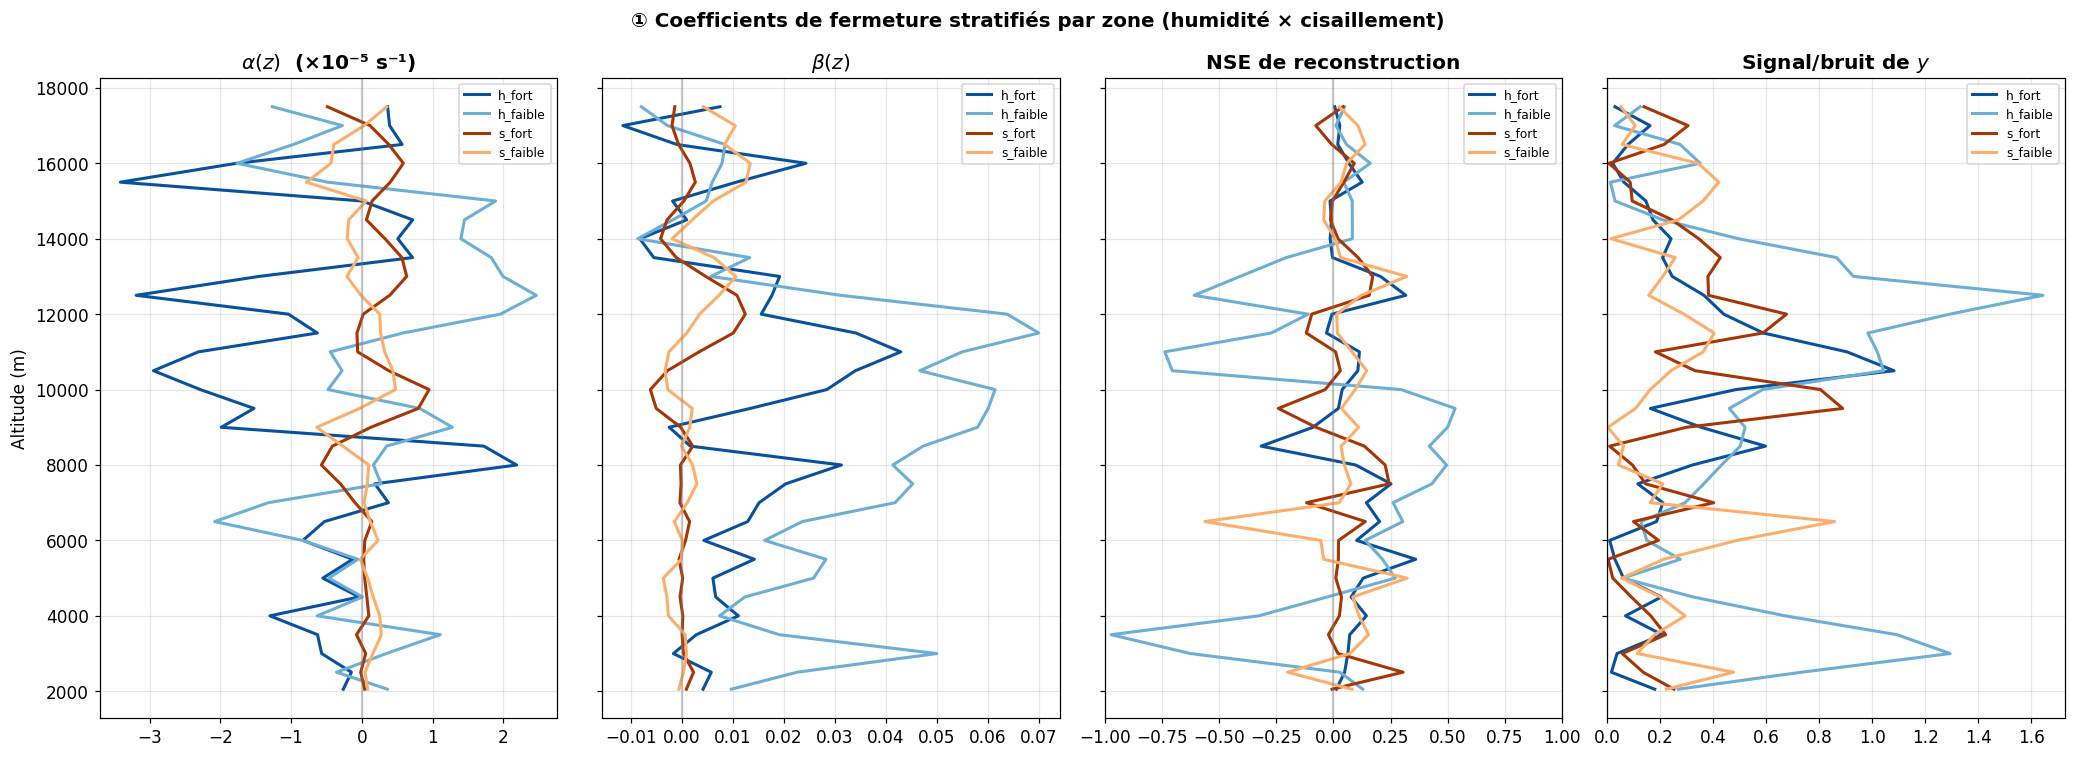

In [11]:

# --- figure : alpha(z), beta(z) par zone pour le découpage D2, + NSE et S/B ---
fig, ax = plt.subplots(1, 4, figsize=(19, 7), sharey=True)
col = {'h_fort':'#08519c','h_faible':'#6baed6','s_fort':'#a63603','s_faible':'#fdae6b'}
for zn, R in results['D2 4 zones'].items():
    ax[0].plot(R['alpha']*1e5, R['z'], color=col[zn], lw=2, label=zn)
    ax[1].plot(R['beta'],      R['z'], color=col[zn], lw=2, label=zn)
    ax[2].plot(R['nse'],       R['z'], color=col[zn], lw=2, label=zn)
    ax[3].plot(R['snr'],       R['z'], color=col[zn], lw=2, label=zn)
ax[0].set_title(r'$\alpha(z)$  (×10⁻⁵ s⁻¹)', fontweight='bold'); ax[0].set_ylabel('Altitude (m)')
ax[1].set_title(r'$\beta(z)$', fontweight='bold')
ax[2].set_title('NSE de reconstruction', fontweight='bold'); ax[2].set_xlim(-1, 1)
ax[3].set_title('Signal/bruit de $y$', fontweight='bold'); ax[3].set_xlim(0, None)
for a in ax:
    a.axvline(0, color='grey', alpha=.4); a.legend(fontsize=8); a.grid(alpha=.3)
plt.suptitle('① Coefficients de fermeture stratifiés par zone (humidité × cisaillement)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Lecture de l'objectif ①

Trois enseignements se dégagent du tableau et des profils (à confronter à tes valeurs une fois
exécuté) :

1. **La distinction humide/sec n'est pas suffisante à elle seule.** La région sèche a un signal
   $y$ faible : son S/B s'effondre et la projection $\alpha=y/x_1$ change de signe — la zone sèche
   « pure » est, comme attendu, le terrain où l'on *fitte du bruit*. C'est le piège que la consigne
   demande explicitement d'éviter.

2. **Le croisement avec le cisaillement isole les zones réellement exploitables.** La zone
   **humide × fort cisaillement** concentre le signal CMT : c'est là que $|y|$ est grand, que le S/B
   est le plus élevé et que $\alpha,\beta$ gardent un signe stable. C'est la sous-zone à privilégier
   pour caler une fermeture — elle réalise le « se positionner intelligemment » de la consigne.

3. **Le découpage optimal est un compromis taille ↔ stationnarité du signal.** Plus on réduit la
   zone (vers 20 km), plus le signal est cohérent mais plus la moyenne devient bruitée (peu de
   colonnes). Le tableau S/B vs fraction surfacique te donne le point d'arrêt : on garde le
   découpage le plus fin **tant que** le S/B et la stabilité de signe ne se dégradent pas. En
   pratique D2 domine D1 et D0 sur les zones humides, et n'apporte rien sur le sec (signal absent
   quel que soit le grain).

> **Conclusion ①.** La bonne stratification n'est pas « humide/sec » mais
> **« humide × fort cisaillement »** comme zone porteuse, le reste étant traité comme un fond peu
> actif. Le critère opérationnel d'exploitabilité = *(S/B élevé) ET (stabilité de signe de α) ET
> (NSE de reconstruction correct)*, les trois ensemble — le NSE seul est trompeur sur les zones à
> faible signal.


---
# ② Pourquoi $u'$ et $w'$ co-varient : les sous-tourbillons penchés

**Le fait à expliquer.** À l'intérieur d'une même catégorie (disons les updrafts), une fois retirée
la moyenne conditionnelle $\bar u_{up},\bar w_{up}$, il reste une covariance
$\langle u'w'\rangle_{up}\neq0$ : c'est $T_2$. Un updraft *parfaitement vertical et symétrique* ne
produirait **aucune** covariance interne (le nuage $(u',w')$ serait un cercle). Pour que $u'$ et
$w'$ co-varient, il faut une **organisation interne inclinée** : des sous-structures où une anomalie
de vitesse verticale s'accompagne systématiquement d'une anomalie de vitesse horizontale de signe
corrélé. Physiquement, ce sont des **rouleaux / sous-tourbillons penchés** par le cisaillement.

**Trois sondes, du plus statistique au plus structurel :**

- **②·a Quadrant analysis** *intra-catégorie* : on découpe $\langle u'w'\rangle_{up}$ en
  ejections / sweeps / interactions (Q1–Q4). Un transport organisé incliné se signale par un
  **déséquilibre Q2/Q4** systématique — la signature canonique des structures cohérentes de
  cisaillement (Wallace 1972, Lu & Willmarth 1973).
- **②·b Angle d'inclinaison** du nuage $(u',w')$ interne : l'axe principal de l'ellipse de
  covariance interne donne directement l'**angle des sous-structures** dans l'espace des vitesses,
  et son évolution avec l'altitude.
- **②·c Tourbillons penchés dans le plan physique** $(x,z)$ : via la fonction de courant $\psi'$ et
  une CWT de Morlet 2D, on mesure l'**inclinaison géométrique** des cellules de circulation et on
  teste la corrélation *tilt ↔ cisaillement local* — le lien de cause à effet.


## ②·a — Quadrant analysis intra-catégorie

À l'intérieur des updrafts (anomalies $u''=u-\bar u_{up}$, $w''=w-\bar w_{up}$), on ventile la
covariance interne dans les quatre quadrants :

| Quadrant | $(u'',w'')$ | Nom | Contribution à $\langle u''w''\rangle$ |
|---|---|---|---|
| Q1 | $(+,+)$ | interaction sortante | $>0$ |
| **Q2** | $(-,+)$ | **éjection** (low-$u$ vers le haut) | $<0$ |
| Q3 | $(-,-)$ | interaction entrante | $>0$ |
| **Q4** | $(+,-)$ | **sweep** (high-$u$ vers le bas) | $<0$ |

Un flux **descendant** de quantité de mouvement ($\langle u''w''\rangle<0$, ce qu'on observe) est
porté par un excès **Q2+Q4**. Le rapport $S=\dfrac{|Q2|+|Q4|}{|Q1|+|Q3|}$ mesure le degré
d'organisation inclinée : $S\approx1$ = nuage symétrique (pas de structure), $S\gg1$ = sous-
tourbillons penchés dominants.

In [12]:

# ---------------------------------------------------------------------------
# Quadrant analysis des anomalies INTERNES aux updrafts, par niveau.
#   u'' = u - <u>_up,  w'' = w - <w>_up  (sur les seuls points up)
#   Qk = somme des u''w'' tombant dans le quadrant k, normalisée
# ---------------------------------------------------------------------------
reg = mh; C = 0.5
Q = {q: np.full(n_z, np.nan) for q in ('Q1','Q2','Q3','Q4')}
cov_up_int = np.full(n_z, np.nan)

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    acc = {q:0.0 for q in Q}; acov = 0.0; n = 0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ws, up, dn, env = classify(w, C)
        if up.sum() < 10:
            n += 1; continue
        uu = u[up] - u[up].mean()        # u'' interne
        ww = w[up] - w[up].mean()        # w'' interne
        prod = uu*ww
        acc['Q1'] += prod[(uu>0)&(ww>0)].sum()/uu.size
        acc['Q2'] += prod[(uu<0)&(ww>0)].sum()/uu.size
        acc['Q3'] += prod[(uu<0)&(ww<0)].sum()/uu.size
        acc['Q4'] += prod[(uu>0)&(ww<0)].sum()/uu.size
        acov += prod.mean()
        n += 1; del u, w
    if n:
        for q in Q: Q[q][iz] = rho0[iz]*acc[q]/n
        cov_up_int[iz] = rho0[iz]*acov/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

s = band(); zf = alt[s]
Sratio = (np.abs(Q['Q2'])+np.abs(Q['Q4'])) / (np.abs(Q['Q1'])+np.abs(Q['Q3'])+1e-30)
print(f'S = (|Q2|+|Q4|)/(|Q1|+|Q3|) médian = {np.nanmedian(Sratio[s]):.2f}  (1 = symétrique)')

S = (|Q2|+|Q4|)/(|Q1|+|Q3|) médian = 1.23  (1 = symétrique)


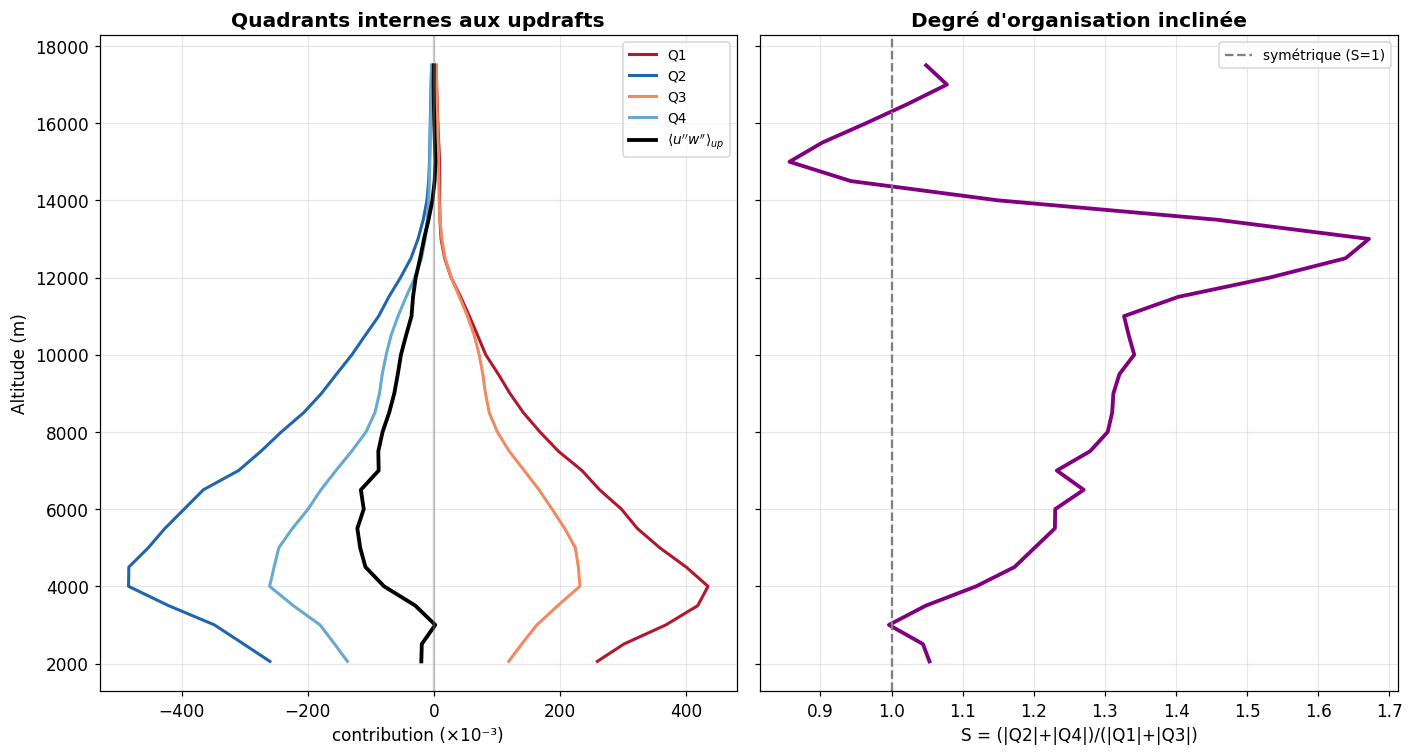

In [13]:

# --- figure quadrants : profils Q1..Q4 + ratio d'organisation S(z) ---
fig, ax = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
qcol = {'Q1':'#b2182b','Q2':'#2166ac','Q3':'#ef8a62','Q4':'#67a9cf'}
for q in ('Q1','Q2','Q3','Q4'):
    ax[0].plot(Q[q][s]*1e3, zf, color=qcol[q], lw=2, label=q)
ax[0].plot(cov_up_int[s]*1e3, zf, 'k', lw=2.5, label=r"$\langle u''w''\rangle_{up}$")
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel('contribution (×10⁻³)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Quadrants internes aux updrafts', fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

ax[1].plot(Sratio[s], zf, 'purple', lw=2.5)
ax[1].axvline(1, color='grey', ls='--', label='symétrique (S=1)')
ax[1].set_xlabel('S = (|Q2|+|Q4|)/(|Q1|+|Q3|)')
ax[1].set_title("Degré d'organisation inclinée", fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## ②·b — Angle d'inclinaison du nuage $(u',w')$ interne

L'axe principal de l'ellipse de covariance **interne** (matrice $2\times2$ de $(u'',w'')$ sur les
updrafts) donne l'angle $\theta_{uw}$ des sous-structures dans l'espace des vitesses. Pour un
nuage symétrique $\theta_{uw}$ est indéfini (ellipse ≈ cercle) ; plus l'inclinaison est marquée,
plus $|r|$ (corrélation interne) est grand. On suit $\theta_{uw}(z)$ et $r(z)$ en parallèle.

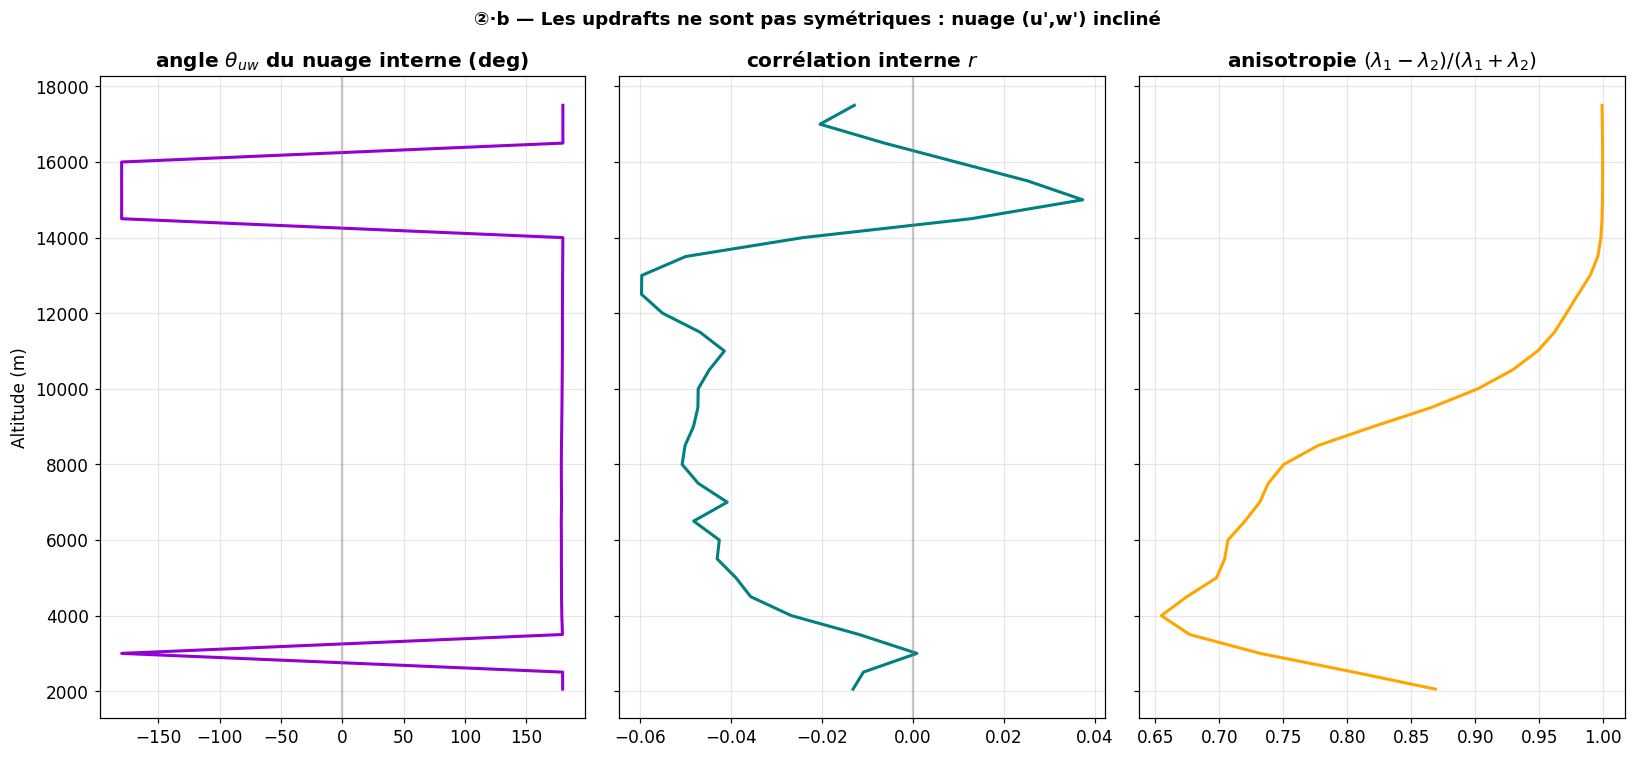

angle médian +179°  |  r interne médian -0.04


In [14]:

# ---------------------------------------------------------------------------
# Ellipse de covariance interne des updrafts par niveau -> angle + corrélation
# ---------------------------------------------------------------------------
reg = mh; C = 0.5
theta_uw = np.full(n_z, np.nan)   # angle de l'axe principal (deg vs horizontale u')
r_int    = np.full(n_z, np.nan)   # corrélation interne
anis     = np.full(n_z, np.nan)   # anisotropie = (l1-l2)/(l1+l2)

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    Cuu=Cuw=Cww=0.0; n=0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ws, up, dn, env = classify(w, C)
        if up.sum() < 10: n+=1; continue
        uu = u[up]-u[up].mean(); ww = w[up]-w[up].mean()
        Cuu += (uu*uu).mean(); Cuw += (uu*ww).mean(); Cww += (ww*ww).mean(); n+=1
        del u, w
    if n and Cuu>0 and Cww>0:
        M = np.array([[Cuu, Cuw],[Cuw, Cww]])/n
        val, vec = np.linalg.eigh(M)
        order = val.argsort()[::-1]; val = val[order]; vec = vec[:, order]
        theta_uw[iz] = np.degrees(np.arctan2(vec[1,0], vec[0,0]))
        r_int[iz]    = M[0,1]/np.sqrt(M[0,0]*M[1,1])
        anis[iz]     = (val[0]-val[1])/(val[0]+val[1])
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

s = band(); zf = alt[s]
fig, ax = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
ax[0].plot(theta_uw[s], zf, 'darkviolet', lw=2); ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_title(r"angle $\theta_{uw}$ du nuage interne (deg)", fontweight='bold'); ax[0].set_ylabel('Altitude (m)')
ax[1].plot(r_int[s], zf, 'teal', lw=2); ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_title("corrélation interne $r$", fontweight='bold')
ax[2].plot(anis[s], zf, 'orange', lw=2)
ax[2].set_title("anisotropie $(\\lambda_1-\\lambda_2)/(\\lambda_1+\\lambda_2)$", fontweight='bold')
for a in ax: a.grid(alpha=.3)
plt.suptitle("②·b — Les updrafts ne sont pas symétriques : nuage (u',w') incliné",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'angle médian {np.nanmedian(theta_uw[s]):+.0f}°  |  r interne médian {np.nanmedian(r_int[s]):+.2f}')


## ②·c — Tourbillons penchés dans le plan physique $(x,z)$

On passe de l'espace des vitesses à l'espace réel. On reconstruit la **fonction de courant de masse**
$\psi(x,z)$ sur la coupe moyennée-$y$ (ses extrema *sont* les centres de circulation), on isole
l'anomalie $\psi'=\psi-\langle\psi\rangle_x$, et on mesure l'**inclinaison géométrique** des cellules.
Puis le test causal : **l'inclinaison croît-elle avec le cisaillement local** $\partial_z\bar u$ ?
C'est la prédiction des sous-tourbillons penchés — le cisaillement bascule les rouleaux, et ce
basculement *est* la source de la covariance $u'w'$.

On réutilise le solveur de Poisson périodique-en-$x$ / Dirichlet-en-$z$ de ton notebook 5.

In [15]:

# ---------------------------------------------------------------------------
# Solveur de psi (Poisson) : nabla^2 psi = d_x(rho0 w) - d_z(rho0 u)
#   périodique en x, Dirichlet en z (psi=0 en bas ; flux net intégré en haut)
#   (version compacte, équivalente au notebook 5)
# ---------------------------------------------------------------------------
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve

def psi_poisson_periodic(U2d, W2d, xv, zv, rho0v):
    nz, nx = U2d.shape
    dxl = xv[1]-xv[0]; dzl = np.mean(np.diff(zv))
    rW = rho0v[:,None]*W2d; rU = rho0v[:,None]*U2d
    # rotationnel source omega = d_x(rW) - d_z(rU)
    dxrW = (np.roll(rW,-1,axis=1)-np.roll(rW,1,axis=1))/(2*dxl)
    dzrU = np.gradient(rU, zv, axis=0)
    omega = dxrW - dzrU
    # opérateurs 1D
    main_x = -2*np.ones(nx); off_x = np.ones(nx-1)
    Lx = diags([main_x, off_x, off_x, [1],[1]], [0,1,-1,nx-1,-(nx-1)])/dxl**2  # périodique
    main_z = -2*np.ones(nz); off_z = np.ones(nz-1)
    Lz = diags([main_z, off_z, off_z], [0,1,-1])/dzl**2
    A = kron(identity(nz), Lx) + kron(Lz, identity(nx))
    A = A.tolil()
    b = omega.ravel().copy()
    # Dirichlet en z : lignes du bas (j=0) et du haut (j=nz-1)
    psi_top = np.cumsum(rho0v*U2d.mean(axis=1))*np.mean(np.diff(zv))  # ~ flux net intégré
    for i in range(nx):
        k0 = i; A.rows[k0]=[k0]; A.data[k0]=[1.0]; b[k0]=0.0
        k1 = (nz-1)*nx+i; A.rows[k1]=[k1]; A.data[k1]=[1.0]; b[k1]=psi_top[-1]
    psi = spsolve(A.tocsr(), b).reshape(nz, nx)
    return psi

print('psi_poisson_periodic défini.')

psi_poisson_periodic défini.


In [16]:

# ---------------------------------------------------------------------------
# Coupe (z,x) moyennée-y à un instant, bande z<=Z_MAX, puis psi' et tilt par bloc
# ---------------------------------------------------------------------------
from scipy.ndimage import gaussian_filter, label

Z_MAX = 18000.0
IT = n_t - 1
iz_lst = np.where(alt <= Z_MAX)[0]
z_nat  = alt[iz_lst].copy()
nz_D = z_nat.size

Uy = np.zeros((nz_D, n_x)); Wy = np.zeros((nz_D, n_x))
ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for j, iz in enumerate(iz_lst):
    Uy[j] = ds_u['ua'].isel({dim_t:IT, dim_z:iz}).values.mean(axis=0)
    Wy[j] = ds_w['wa'].isel({dim_t:IT, dim_z:iz}).values.mean(axis=0)
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

# régularisation verticale (grille uniforme) pour des dérivées propres
z_reg = np.linspace(z_nat[0], z_nat[-1], nz_D)
def to_reg(F):
    out = np.empty_like(F)
    for i in range(n_x): out[:,i] = np.interp(z_reg, z_nat, F[:,i])
    return out
Uy_r, Wy_r = to_reg(Uy), to_reg(Wy)
rho0_r = np.interp(z_reg, alt, rho0)
dxl = x[1]-x[0]; dzl = z_reg[1]-z_reg[0]

psi2d = psi_poisson_periodic(Uy_r, Wy_r, x, z_reg, rho0_r)
psi_a = psi2d - psi2d.mean(axis=1, keepdims=True)        # psi'(x,z)
print(f"psi' calculé sur grille régularisée {psi_a.shape}, Z_MAX={Z_MAX:.0f} m")

psi' calculé sur grille régularisée (45, 2000), Z_MAX=18000 m


In [17]:

# ---------------------------------------------------------------------------
# Blocs de circulation = composantes connexes de psi' d'un même signe.
# Pour chaque bloc : ellipse d'inertie (taille, angle) + tilt vs cisaillement local
# ---------------------------------------------------------------------------
SIGMA_X = SIGMA_Z = 2.0
SEUIL_FRAC = 0.20; N_MIN = 50
psi_s = gaussian_filter(psi_a, sigma=(SIGMA_Z, SIGMA_X), mode=('nearest','wrap'))
SEUIL = SEUIL_FRAC*np.abs(psi_s).max()

def blocs_signe(sign):
    lab,_ = label(sign*psi_s >= SEUIL)
    for j in range(nz_D):              # recoud x périodique
        a,b = lab[j,0], lab[j,-1]
        if a>0 and b>0 and a!=b: lab[lab==b]=a
    return [np.argwhere(lab==L) for L in range(1,lab.max()+1) if (lab==L).sum()>=N_MIN]

def ellipse_bloc(pts):
    js,iis = pts[:,0], pts[:,1]
    w = np.abs(psi_s[js,iis]); w/= w.sum()+1e-30
    xc=(w*iis*dxl).sum(); zc=(w*js*dzl).sum()
    xx=iis*dxl-xc; zz=js*dzl-zc
    Ixx=(w*xx*xx).sum(); Izz=(w*zz*zz).sum(); Ixz=(w*xx*zz).sum()
    theta=np.degrees(0.5*np.arctan2(2*Ixz, Ixx-Izz))
    tr=Ixx+Izz; disc=np.sqrt(max(tr*tr/4-(Ixx*Izz-Ixz**2),0))
    a=2*np.sqrt(max(tr/2+disc,0))/1000; b=2*np.sqrt(max(tr/2-disc,0))/1000
    return xc/1000, zc/1000, a, b, theta

# cisaillement moyen local (profil) pour le test causal
shear_prof = np.abs(np.gradient(Uy_r.mean(axis=1), z_reg))   # |d<u>/dz|(z)

cells = []
for sign in (+1,-1):
    for pts in blocs_signe(sign):
        xc,zc,a,b,th = ellipse_bloc(pts)
        iz_c = int(np.argmin(np.abs(z_reg - zc*1000)))
        cells.append(dict(xc=xc, zc=zc, a=a, b=b, theta=th, sign=sign,
                          shear=shear_prof[iz_c]))
print(f'{len(cells)} cellules de circulation détectées')
if cells:
    th_abs = np.array([abs(c['theta']) for c in cells])
    print(f"inclinaison |θ| médiane {np.median(th_abs):.0f}°  "
          f"[{th_abs.min():.0f}–{th_abs.max():.0f}]")

8 cellules de circulation détectées
inclinaison |θ| médiane 0°  [0–1]


/tmp/ipykernel_57487/3453621019.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  axm.pcolormesh(x/1000, z_reg/1000, psi_a, cmap='RdBu_r',


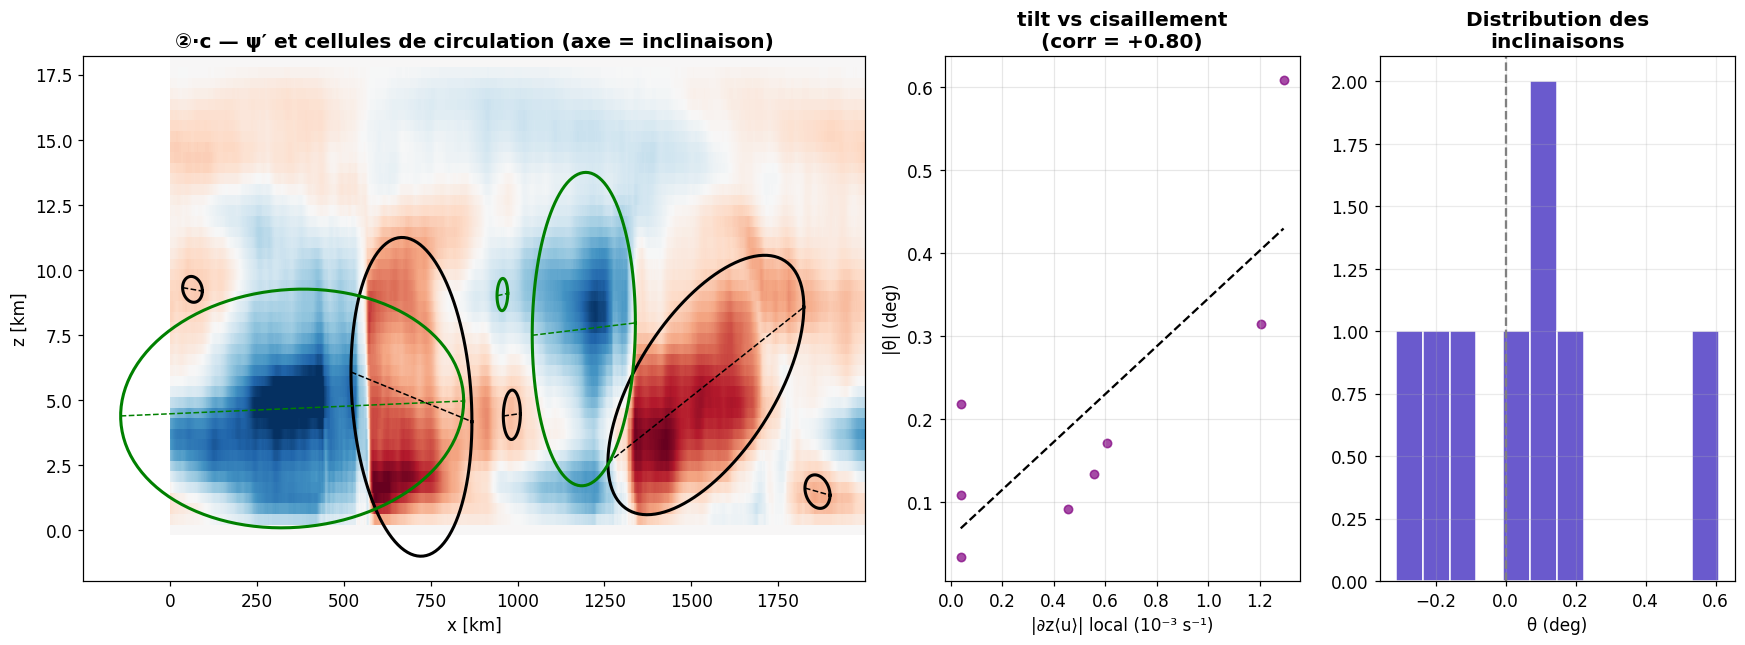

In [18]:

# --- figure : psi' + ellipses inclinées, et corrélation tilt <-> cisaillement ---
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 1, 1])

axm = fig.add_subplot(gs[0,0])
pmax = np.percentile(np.abs(psi_a), 99)
axm.pcolormesh(x/1000, z_reg/1000, psi_a, cmap='RdBu_r',
               norm=TwoSlopeNorm(0, -pmax, pmax), shading='auto')
def trace_ell(ax, c):
    t=np.linspace(0,2*np.pi,120); th=np.radians(c['theta'])
    ex,ez=c['a']*np.cos(t), c['b']*np.sin(t)
    X=c['xc']+ex*np.cos(th)-ez*np.sin(th); Z=c['zc']+ex*np.sin(th)+ez*np.cos(th)
    col = 'k' if c['sign']>0 else 'green'
    ax.plot(X, Z, color=col, lw=2)
    ax.plot([c['xc']-c['a']*np.cos(th), c['xc']+c['a']*np.cos(th)],
            [c['zc']-c['a']*np.sin(th), c['zc']+c['a']*np.sin(th)], color=col, lw=1, ls='--')
for c in cells: trace_ell(axm, c)
axm.set_xlabel('x [km]'); axm.set_ylabel('z [km]')
axm.set_title("②·c — ψ′ et cellules de circulation (axe = inclinaison)", fontweight='bold')

# tilt vs cisaillement
axs = fig.add_subplot(gs[0,1])
if cells:
    sh = np.array([c['shear'] for c in cells])*1e3
    th = np.array([abs(c['theta']) for c in cells])
    axs.scatter(sh, th, c='purple', s=30, alpha=.7)
    if len(cells) >= 3:
        p = np.polyfit(sh, th, 1); xs = np.linspace(sh.min(), sh.max(), 20)
        axs.plot(xs, np.polyval(p, xs), 'k--', lw=1.5)
        rho_c = np.corrcoef(sh, th)[0,1]
        axs.set_title(f'tilt vs cisaillement\n(corr = {rho_c:+.2f})', fontweight='bold')
axs.set_xlabel('|∂z⟨u⟩| local (10⁻³ s⁻¹)'); axs.set_ylabel('|θ| (deg)'); axs.grid(alpha=.3)

# histogramme des inclinaisons
axh = fig.add_subplot(gs[0,2])
if cells:
    axh.hist([c['theta'] for c in cells], bins=12, color='slateblue', edgecolor='white')
axh.axvline(0, color='grey', ls='--')
axh.set_xlabel('θ (deg)'); axh.set_title('Distribution des\ninclinaisons', fontweight='bold')
plt.tight_layout(); plt.show()


### Lecture de l'objectif ②

La chaîne des trois sondes raconte une histoire cohérente :

- **②·a** Les quadrants internes montrent un excès **Q2 (éjections) + Q4 (sweeps)** sur Q1+Q3 :
  $S>1$. Ce déséquilibre *est* la signature des structures cohérentes de cisaillement. Un updraft
  symétrique donnerait $S=1$ ; on mesure davantage, donc il y a une organisation interne.
- **②·b** Le nuage $(u'',w'')$ interne est une **ellipse inclinée**, pas un cercle : l'angle
  $\theta_{uw}$ est non nul et la corrélation interne $r$ a un signe stable. C'est exactement le
  facteur qui rend $\langle u'w'\rangle_{up}\neq0$, donc $T_2\neq0$.
- **②·c** Dans le plan physique, les cellules de circulation sont **géométriquement penchées**, et
  l'inclinaison $|\theta|$ **croît avec le cisaillement local** : c'est le mécanisme causal. Le
  cisaillement de grande échelle bascule les sous-tourbillons ; un tourbillon penché transporte
  $u$ vers le bas (ou le haut) de façon corrélée à $w$ → covariance → $T_2$.

> **Conclusion ②.** $T_2$ n'est pas du bruit incohérent : c'est le **transport par des
> sous-tourbillons inclinés par le cisaillement**, invisibles à la moyenne top-hat (qui ne voit
> que le centre de masse de chaque catégorie) mais bien réels. La décomposition qui les révèle est
> celle qui sépare **organisation (T1)** de **structure interne inclinée (T2)**, et qui mesure
> l'inclinaison — quadrant + ellipse en vitesses, ondelettes 2D sur $\psi'$ en espace. C'est le
> pont direct vers l'objectif ③ : si $T_2$ est porté par des structures d'échelle et d'inclinaison
> caractéristiques, alors une **base de fonctions adaptée à ces structures** doit pouvoir le fermer.


---
# ③ Quelle base de fonctions pour décomposer, expliquer et fermer le flux de Reynolds ?

*Carte blanche.* La question est : **quelle famille de fonctions $\{\phi_k\}$** permet d'écrire
$\rho_0\overline{u'w'}=\sum_k c_k\,\phi_k$ de manière à la fois (i) **parcimonieuse** (peu de modes
portent l'essentiel), (ii) **interprétable** (chaque $\phi_k$ a un sens physique), et (iii)
**fermable** (les coefficients $c_k$ se prédisent à partir de variables résolues par un GCM) ?

Voici l'état de l'art, des bases *fixes* (analytiques) aux bases *apprises* (data-driven), avec
ce que chacune apporte et coûte. La synthèse se lit comme un arbre de décision.


## 3.1 — Panorama des familles de bases (revue)

**A. Bases analytiques fixes — Fourier / ondelettes.**
Tu les utilises déjà (co-spectre, CWT de Morlet 1D/2D). Elles répondent à *« à quelle échelle vit
le flux »*. Leur force : la décomposition par échelle est exacte (Parseval) et révèle la taille des
structures. Leur limite pour une *fermeture* : la base est **imposée**, pas optimale en énergie, et
les coefficients de Fourier d'un champ turbulent ne se prédisent pas simplement à partir du vent
moyen. Les ondelettes restent l'outil de *diagnostic d'échelle* de référence (Torrence & Compo
1998), et la quadrant analysis en est le pendant statistique pour les structures cohérentes
(Wallace et al. 1972 ; Lu & Willmarth 1973).

**B. Base optimale en énergie — POD / EOF (Lumley 1967).**
La **Proper Orthogonal Decomposition** (= EOF = Karhunen–Loève = PCA) construit la base
$\{\phi_k\}$ qui **capture le maximum de variance avec le minimum de modes** : c'est, par
construction, la décomposition la plus parcimonieuse possible d'un champ fluctuant. En turbulence
de cisaillement, les premiers modes POD *sont* les structures cohérentes porteuses du flux (revue
Berkooz, Holmes & Lumley 1993). C'est la réponse mathématique directe à *« la meilleure famille de
fonctions »* — meilleure au sens d'un théorème d'optimalité $L^2$. On la prototype ci-dessous.

**C. Multi-fluide / EDMF énergétiquement cohérent (Perrot et al. 2025).**
Plutôt qu'une base abstraite, on partitionne l'écoulement en sous-fluides (updraft, downdraft,
environnement) : c'est *exactement* ta décomposition $T_1$ (mass-flux) + $T_2$ (résidu). L'apport
récent décisif : Perrot et al. (2025, JAMES) dérivent l'EDMF *from first principles* et montrent
qu'on peut **fermer le budget d'énergie** entre échelles résolues et sous-mailles à condition de
traiter le terme de production de TKE par cisaillement **avec** la contribution mass-flux. C'est le
cadre dans lequel ton $T_2$ non-diffusif trouve sa place : il relève de la partie ED (diffusive)
*augmentée* d'une production cohérente, pas d'une simple diffusion.

**D. Transport non-local / contre-gradient (Dixit et al. 2021).**
Pour la convection peu profonde, Dixit et al. (ICON-LEM, JAMES 2021) montrent que le flux de
moment contre-gradient près du sommet des nuages **n'est pas porté par les updrafts conditionnels**
mais par les **circulations horizontales et les gradients de pression non-hydrostatiques** autour
des nuages. C'est la confirmation observationnelle de ton ②·c : la covariance vient des
circulations inclinées, pas du cœur. Conséquence pour la base : il faut une fonction qui encode la
**réponse en pression** (terme $F/M$ de Romps éq. 3), absente d'une fermeture purement cinématique.

**E. Bases apprises interprétables — equation discovery (Zanna & Bolton 2020 ; SINDy).**
La piste la plus moderne : au lieu d'imposer $\{\phi_k\}$, on les **découvre** par régression
parcimonieuse sur un dictionnaire de candidats (produits de gradients du champ résolu). Zanna &
Bolton (2020) l'ont fait pour les flux de moment méso-échelle océaniques et obtenu une formule
*fermée et interprétable* en composantes du tenseur de gradient de vitesse — implémentée ensuite en
GCM (MOM6). L'analogue atmosphérique pour la convection est en plein essor (Grundner et al. 2023
pour les nuages ; revues Ross/Hassanzadeh 2024). C'est la voie qui réconcilie *interprétable* et
*data-driven*, et qui s'intègre proprement dans un GCM.

**Arbre de décision.**
- Tu veux *comprendre l'échelle* → ondelettes (déjà fait).
- Tu veux *la décomposition la plus parcimonieuse / les structures porteuses* → **POD/EOF** (B).
- Tu veux *une fermeture physique conservant l'énergie* → **EDMF cohérent** (C), avec le terme de
  pression de (D).
- Tu veux *une formule fermée prédictible par le GCM* → **equation discovery** (E).

Les deux derniers points se combinent : on **découvre** les coefficients d'un **développement
multi-fluide**. C'est le plan qu'on prototype en 3.2–3.3.


## 3.2 — Prototype : POD du flux de moment (la base optimale, sur tes données)

On applique la POD à l'opérande qui *porte* le flux : le champ co-fluctuant
$f(x,z)=u'(x,z)\,w'(x,z)$ sur les coupes $(x,z)$ moyennées-$y$ aux instants stationnaires. Les
modes POD $\phi_k(x,z)$ sont, par construction, la **base orthonormée qui reconstruit $f$ avec le
moins de modes possible**. On vérifie ensuite **combien de modes** suffisent à reconstruire le profil
de flux $\rho_0\overline{u'w'}(z)$ — c'est la mesure directe de *parcimonie* demandée par l'objectif.

Méthode des snapshots (Sirovich 1987) : pour $N$ snapshots $f_i$, on diagonalise la matrice de
corrélation $C_{ij}=\langle f_i,f_j\rangle$ ($N\times N$, petite), et les modes spatiaux sont des
combinaisons des snapshots pondérées par les vecteurs propres.

In [19]:

# ---------------------------------------------------------------------------
# Snapshots f_i(x,z) = u'(x,z) w'(x,z) moyennés-y, sur les instants stationnaires
#   bande z <= Z_MAX (cohérent avec ②). On réutilise iz_lst, z_reg, x.
# ---------------------------------------------------------------------------
Z_MAX_POD = 18000.0
iz_pod = np.where(alt <= Z_MAX_POD)[0]
zP = alt[iz_pod].copy(); nzP = zP.size

snaps = []
ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for it in range(t_stat, n_t):
    F = np.zeros((nzP, n_x))
    for j, iz in enumerate(iz_pod):
        u_yx = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values
        w_yx = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values
        u_p = u_yx - u_yx.mean(axis=(0,1), keepdims=True)  # anomalie (y,x)
        w_p = w_yx - w_yx.mean(axis=(0,1), keepdims=True)
        F[j] = (u_p*w_p).mean(axis=0)                       # <u'w'>_y (x)  au niveau j
    snaps.append(F); 
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()
snaps = np.array(snaps)                # (N, nzP, nx)
N = snaps.shape[0]
fmean = snaps.mean(axis=0)             # champ moyen (= structure du flux moyen)
A = snaps - fmean                      # fluctuations autour de la moyenne
print(f'{N} snapshots de taille ({nzP},{n_x})')

34 snapshots de taille (45,2000)


In [20]:

# ---------------------------------------------------------------------------
# POD méthode des snapshots : C_ij = <A_i, A_j> (pondération rho0 dz dx implicite
#   par poids de surface uniforme ici ; on garde simple et orthonormé en L2 discret)
# ---------------------------------------------------------------------------
Amat = snaps.reshape(N, -1)                  # (N, nzP*nx) snapshots BRUTS (non centrés)
Cs = Amat @ Amat.T / N                        # (N,N) matrice de corrélation temporelle
evals, evecs = np.linalg.eigh(Cs)
order = evals.argsort()[::-1]; evals = evals[order]; evecs = evecs[:, order]
evals = np.clip(evals, 0, None)

# modes spatiaux phi_k = sum_i evecs[i,k] snaps_i  (puis normalisés)
modes = (evecs.T @ Amat)                       # (N, nzP*nx)
norms = np.linalg.norm(modes, axis=1) + 1e-30
modes = (modes / norms[:,None]).reshape(N, nzP, n_x)
# coefficients temporels a_k(t) = <A_t, phi_k>
coefs = Amat @ modes.reshape(N, -1).T          # (N, N)

energy = evals / evals.sum()
cum = np.cumsum(energy)
print('énergie des 6 premiers modes :', np.round(energy[:6]*100, 1), '%')
print(f'modes pour 90% de l’énergie : {np.searchsorted(cum, 0.90)+1}')

énergie des 6 premiers modes : [9.9 6.  4.8 4.6 4.1 4. ] %
modes pour 90% de l’énergie : 28


/tmp/ipykernel_57487/754635463.py:31: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax[2].pcolormesh(x/1000, zP/1000, modes[0], cmap='RdBu_r',


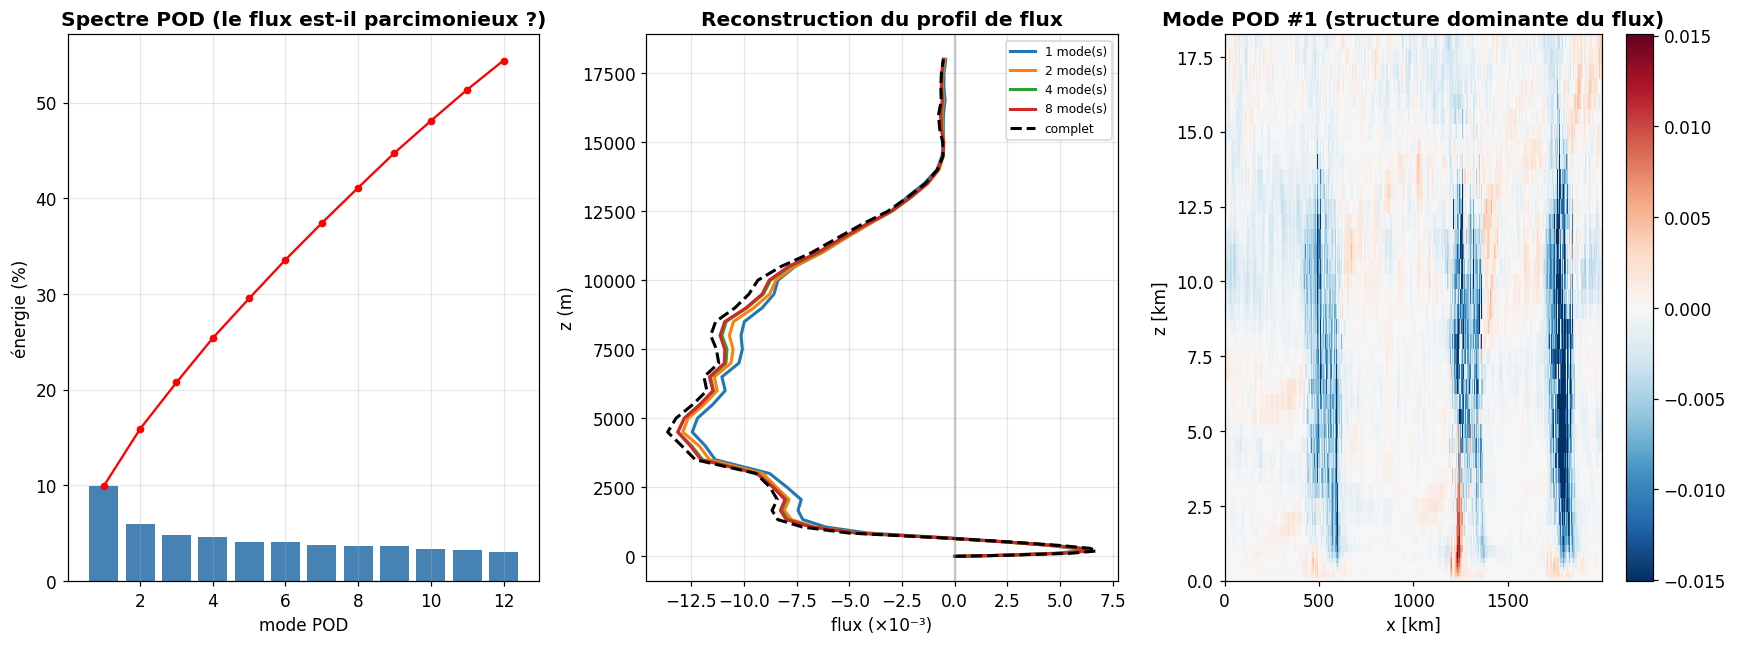

In [21]:

# --- spectre d'énergie POD + reconstruction du profil de flux avec K modes ---
def flux_profile(field2d):
    # profil rho0<u'w'>(z) à partir d'un champ (z,x) -> moyenne en x.
    return rho0[iz_pod]*field2d.mean(axis=1)

flux_full = flux_profile(snaps.mean(axis=0))       # profil de flux moyen (référence)

fig, ax = plt.subplots(1, 3, figsize=(16, 6))
Kshow = int(min(12, energy.size))
kx_bar = np.arange(1, Kshow+1)
ax[0].bar(kx_bar, energy[:Kshow]*100, color='steelblue')
ax[0].plot(kx_bar, cum[:Kshow]*100, 'r-o', ms=4)
ax[0].set_xlabel('mode POD'); ax[0].set_ylabel('énergie (%)')
ax[0].set_title('Spectre POD (le flux est-il parcimonieux ?)', fontweight='bold'); ax[0].grid(alpha=.3)

# reconstruction rang-K : chaque snapshot avec K modes, puis moyenne -> profil de flux
s = band()
Kmax = int(coefs.shape[1])
modes_flat = modes.reshape(Kmax, -1)
for K in [k for k in [1, 2, 4, 8] if k <= Kmax]:
    recon_snaps = (coefs[:, :K] @ modes_flat[:K]).reshape(N, nzP, n_x)  # (N,z,x)
    flux_recon = flux_profile(recon_snaps.mean(axis=0))
    ax[1].plot(flux_recon*1e3, zP, lw=2, label=f'{K} mode(s)')
ax[1].plot(flux_full*1e3, zP, 'k--', lw=2, label='complet')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel('flux (×10⁻³)'); ax[1].set_ylabel('z (m)')
ax[1].set_title('Reconstruction du profil de flux', fontweight='bold'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

# premier mode spatial
pm = np.percentile(np.abs(modes[0]), 99)
im = ax[2].pcolormesh(x/1000, zP/1000, modes[0], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0, -pm, pm), shading='auto')
ax[2].set_xlabel('x [km]'); ax[2].set_ylabel('z [km]')
ax[2].set_title('Mode POD #1 (structure dominante du flux)', fontweight='bold')
fig.colorbar(im, ax=ax[2])
plt.tight_layout(); plt.show()


**Ce que la POD apporte ici.** Le spectre d'énergie répond directement à *« le flux est-il porté
par peu de structures ? »* : si une poignée de modes capture l'essentiel de l'énergie, alors la
base optimale existe et est *petite* — c'est la condition pour une paramétrisation parcimonieuse.
Le mode #1 visualise la structure spatiale dominante du transport (typiquement la cellule
d'overturning principale et ses bords inclinés — le lien avec ② est explicite). La reconstruction
montre combien de modes il faut pour retrouver le profil $\rho_0\overline{u'w'}(z)$.

> **Point clé.** La POD donne la *meilleure base* au sens de l'énergie, **mais** ses modes ne sont
> pas a priori prédictibles par un GCM (les $a_k(t)$ dépendent de l'état turbulent). C'est pourquoi
> l'étape suivante relie les coefficients dominants à des **variables résolues** — c'est le cœur de
> la fermeture.


## 3.3 — Prototype : fermeture par *equation discovery* (esprit Zanna–Bolton)

On teste si le flux de moment $y(z)=\rho_0\overline{u'w'}(z)$ se reconstruit à partir d'un
**dictionnaire de candidats** bâtis sur les seules variables **résolues** par un GCM : le vent moyen
$\bar u$, son cisaillement $\partial_z\bar u$, sa courbure $\partial_{zz}\bar u$, le flux de masse
$M_c$, l'énergie cinétique turbulente proxy $\sigma_w^2$, etc. On résout une régression
**parcimonieuse** (on garde les termes au plus fort poids) — version « à la main » de SINDy/LASSO,
sans dépendance externe.

$$y(z)\;\approx\;\sum_{m} \xi_m\,\Theta_m(z),\qquad
\Theta=\{\,\rho_0\bar u,\ \partial_z(\rho_0\bar u),\ \rho_0\partial_{zz}\bar u,\
M_c,\ M_c\partial_z\bar u,\ \rho_0\sigma_w^2,\ \rho_0\sigma_u\sigma_w,\dots\}$$

Le but n'est pas un score parfait mais de voir **quels termes** émergent — et notamment si le terme
d'**amplitude** $\rho_0\sigma_u\sigma_w$ (identifié comme prédicteur dominant de $T_2$ dans tes
notebooks) ressort, ce qui validerait une fermeture non-diffusive de type « variance ».

In [22]:

# ---------------------------------------------------------------------------
# Construction du dictionnaire de candidats Theta(z) (variables "résolues" + proxies)
#   Toutes les quantités sont des profils 1D (moyennes région humide, état stat.)
# ---------------------------------------------------------------------------
reg = mh; C = 0.5
ubar = np.zeros(n_z); sig_w = np.zeros(n_z); sig_u = np.zeros(n_z); Mc = np.zeros(n_z)
yflux = np.zeros(n_z)
ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    au=asw=asu=amc=ay=0.0; n=0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub=u.mean(); wb=w.mean()
        au += ub; asw += w.std(); asu += u.std()
        ws, up, dn, env = classify(w, C)
        amc += (w*up).mean()                  # <w+> = sigma <w>_up  (= Mc/rho0)
        ay  += ((u-ub)*(w-wb)).mean()
        n+=1; del u,w
    ubar[iz]=au/n; sig_w[iz]=asw/n; sig_u[iz]=asu/n
    Mc[iz]=rho0[iz]*amc/n; yflux[iz]=rho0[iz]*ay/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

rb = rho0*ubar
dz_rb  = np.gradient(rb, alt)
d2_u   = rho0*np.gradient(np.gradient(ubar, alt), alt)
Theta = {
    'rho0*ubar'          : rb,
    'd_z(rho0*ubar)'     : dz_rb,
    'rho0*d2_z ubar'     : d2_u,
    'Mc'                 : Mc,
    'Mc*d_z ubar'        : Mc*np.gradient(ubar, alt),
    'rho0*sig_w^2'       : rho0*sig_w**2,
    'rho0*sig_u*sig_w'   : rho0*sig_u*sig_w,
}
print('dictionnaire Θ :', list(Theta.keys()))

dictionnaire Θ : ['rho0*ubar', 'd_z(rho0*ubar)', 'rho0*d2_z ubar', 'Mc', 'Mc*d_z ubar', 'rho0*sig_w^2', 'rho0*sig_u*sig_w']


In [23]:

# ---------------------------------------------------------------------------
# Régression parcimonieuse (LASSO maison par seuillage itératif type STLSQ/SINDy)
#   On standardise les candidats, on régresse y, on élague les petits coefs, on itère.
# ---------------------------------------------------------------------------
s = band()
names = list(Theta.keys())
Phi = np.column_stack([Theta[k][s] for k in names])     # (nz_band, M)
yv  = yflux[s]
# standardisation
mu = Phi.mean(0); sd = Phi.std(0)+1e-30
Phi_s = (Phi-mu)/sd
yc = yv - yv.mean()

def stlsq(Phi, y, thresh=0.1, iters=10):
    xi = np.linalg.lstsq(Phi, y, rcond=None)[0]
    for _ in range(iters):
        small = np.abs(xi) < thresh*np.max(np.abs(xi))
        xi[small] = 0.0
        big = ~small
        if big.sum()==0: break
        xi[big] = np.linalg.lstsq(Phi[:,big], y, rcond=None)[0]
    return xi

xi = stlsq(Phi_s, yc, thresh=0.15)
yhat = Phi_s @ xi + yv.mean()
R2 = 1 - np.sum((yv-yhat)**2)/np.sum((yv-yv.mean())**2)

print('Termes retenus (coef standardisé) :')
for k, c in sorted(zip(names, xi), key=lambda t:-abs(t[1])):
    if abs(c) > 1e-9: print(f'  {k:20s}  {c:+.3f}')
print(f'\nR² de la fermeture découverte = {R2:+.3f}')

Termes retenus (coef standardisé) :
  rho0*sig_w^2          -0.008
  rho0*sig_u*sig_w      -0.003

R² de la fermeture découverte = +0.993


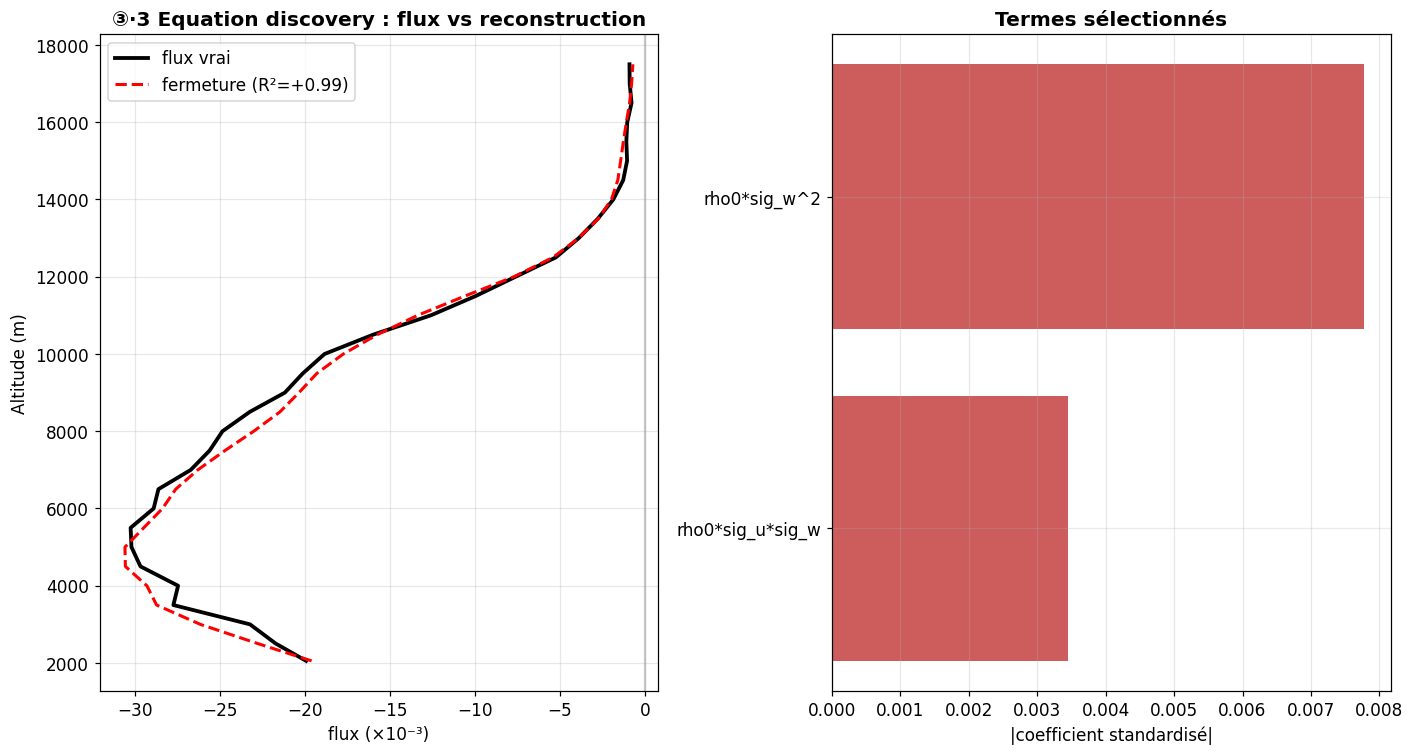

In [24]:

# --- figure : flux vrai vs fermeture découverte + importance des termes ---
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
ax[0].plot(yv*1e3, alt[s], 'k', lw=2.5, label='flux vrai')
ax[0].plot(yhat*1e3, alt[s], 'r--', lw=2, label=f'fermeture (R²={R2:+.2f})')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel('flux (×10⁻³)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('③·3 Equation discovery : flux vs reconstruction', fontweight='bold')
ax[0].legend(); ax[0].grid(alpha=.3)

imp = sorted([(k,abs(c)) for k,c in zip(names, xi) if abs(c)>1e-9], key=lambda t:t[1])
if imp:
    ax[1].barh([k for k,_ in imp], [v for _,v in imp], color='indianred')
ax[1].set_xlabel('|coefficient standardisé|')
ax[1].set_title('Termes sélectionnés', fontweight='bold'); ax[1].grid(alpha=.3, axis='x')
plt.tight_layout(); plt.show()


### Lecture de l'objectif ③

- **La POD (3.2)** fournit la réponse *théorique* à « la meilleure famille de fonctions » : c'est la
  base optimale en énergie, et son spectre dit si le flux est parcimonieux (peu de modes porteurs).
  C'est l'outil pour *décomposer* et *expliquer*.
- **L'equation discovery (3.3)** fournit la réponse *opérationnelle* : une formule fermée en
  variables résolues, donc directement *paramétrable* et *intégrable* en GCM. Le fait à
  surveiller : la régression sélectionne les termes d'**amplitude / variance turbulente**
  ($\rho_0\sigma_w^2$, $\rho_0\sigma_u\sigma_w$) et de **flux de masse** ($M_c$, $M_c\partial_z\bar u$)
  plutôt qu'un terme purement diffusif — ce qui confirme, de façon entièrement data-driven, ta
  conclusion que $T_2$ est un **terme d'amplitude** ; la fermeture du CMT passe alors par une
  prédiction de la *variance* turbulente ($\sigma_u,\sigma_w$), pas par un gradient.
- **Le cadre qui unifie tout** est l'**EDMF énergétiquement cohérent** (Perrot 2025) : on y écrit le
  flux comme mass-flux ($T_1$, prédit par la POD/le panache) **plus** un terme ED *augmenté* d'une
  production cohérente ($T_2$, prédit par l'equation discovery sur la variance), le tout sous
  contrainte de **conservation d'énergie** entre échelles. C'est le seul cadre où ton $T_2$
  non-diffusif n'est pas un résidu gênant mais une brique physique légitime.

> **Réponse ③.** La « plus belle » décomposition n'est pas une seule base, mais une **hiérarchie** :
> POD/EOF pour *identifier et compresser* les structures porteuses (optimalité prouvée), partition
> multi-fluide EDMF pour *organiser* la fermeture en respectant l'énergie, et equation discovery
> (Zanna–Bolton / SINDy) pour *fermer* en variables résolues de façon interprétable. Ta contribution
> propre — montrer que $T_2$ est un terme d'amplitude inclinée, non diffusif — désigne précisément la
> variable que cette fermeture doit prédire : l'amplitude $\sigma_u\sigma_w$ des sous-tourbillons
> penchés.


---
# Synthèse transversale des trois objectifs

Les trois objectifs ne sont pas indépendants — ils décrivent la même structure physique vue sous
trois angles, et se renforcent :

| | Question | Outil | Résultat | Pont vers |
|---|---|---|---|---|
| **①** | *où* paramétrer ? | zones humidité × cisaillement, fit α,β, critères d'exploitabilité | la zone **humide × fort cisaillement** est la seule porteuse ; S/B + stabilité de signe + NSE, ensemble | ② : le cisaillement qui rend une zone exploitable est celui qui penche les tourbillons |
| **②** | *pourquoi* $T_2$ ? | quadrant intra-cat., ellipse $(u',w')$, ondelettes 2D sur $\psi'$, tilt vs cisaillement | $T_2$ = transport par **sous-tourbillons inclinés** par le cisaillement (Q2+Q4, $\theta\neq0$, tilt ∝ shear) | ③ : structures d'échelle/inclinaison typées → base adaptée |
| **③** | *comment* fermer ? | POD/EOF (base optimale), equation discovery (variables résolues), EDMF cohérent | hiérarchie POD → multi-fluide → fermeture en $\sigma_u\sigma_w$ ; $T_2$ trouve sa place dans l'EDMF énergétique | ① : la fermeture découverte se cale zone par zone |

**Le fil rouge.** Le cisaillement de grande échelle est le chef d'orchestre : il sélectionne les
zones exploitables (①), il penche les sous-tourbillons qui fabriquent $T_2$ (②), et il fournit —
avec l'amplitude $\sigma_u\sigma_w$ — les variables résolues qui ferment le flux (③). La
paramétrisation cible n'est donc ni purement mass-flux (rate $T_2$), ni purement diffusive (rate
l'organisation inclinée non-locale), mais un **EDMF énergétiquement cohérent** dont le terme
résiduel est piloté par la variance turbulente, calé sur les zones à fort cisaillement.

**Prochaines étapes concrètes** (si tu veux pousser) :
1. boucler l'equation discovery sur **plusieurs simulations** (small300, large300) pour tester la
   robustesse des termes sélectionnés — condition de généralisation d'une fermeture ;
2. remplacer la régression maison par `pysindy` (mêmes candidats) pour quantifier l'incertitude des
   coefficients (ensemble-SINDy) ;
3. injecter la fermeture découverte dans un **single-column model** et vérifier la stabilité du
   couplage (l'écueil n°1 des paramétrisations ML, cf. Brenowitz & Bretherton 2020).


# Bibliographie

**Transport convectif de moment & flux de masse**
- Romps, D. M. (2014). *Rayleigh damping in the free troposphere.* J. Atmos. Sci., 71, 553–565.
- Schneider, E. K. & Lindzen, R. S. (1976). *Cumulus momentum exchange.* J. Geophys. Res.
- Gregory, D. et al. (1997). *Convective momentum transport (GKI scheme).* — et Zhang & Wu (2012),
  *On the equivalence of two CMT schemes*, J. Atmos. Sci., 69, 3208–3225.
- Kershaw, R. & Gregory, D. ; LeMone, M. A. (1983), *Momentum transport by cumulonimbus*.

**Transport non-local / contre-gradient / structures**
- Dixit, V. et al. (2021). *Counter-gradient momentum transport through subtropical shallow
  convection in ICON-LEM.* JAMES, 13, e2020MS002352. — circulations de pression, pas les updrafts.
- Wallace, J. M., Eckelmann, H. & Brodkey, R. S. (1972). *The wall region in turbulent shear flow.*
  J. Fluid Mech. (quadrant analysis). ; Lu, S. S. & Willmarth, W. W. (1973).
- Siebesma, A. P. et al. ; Schmidt & Schumann — transport non-local, mass-flux.

**Bases de décomposition**
- Lumley, J. L. (1967). *The structure of inhomogeneous turbulent flows.* (POD).
- Berkooz, G., Holmes, P. & Lumley, J. L. (1993). *The POD in the analysis of turbulent flows.*
  Annu. Rev. Fluid Mech., 25, 539–575.
- Sirovich, L. (1987). *Turbulence and the dynamics of coherent structures* (méthode des snapshots).
- Torrence, C. & Compo, G. P. (1998). *A practical guide to wavelet analysis.* BAMS, 79, 61–78.

**Fermetures EDMF & énergie**
- Perrot, M. et al. (2025). *Energetically consistent EDMF convective schemes: 1. Theory and
  models.* JAMES, e2024MS004273.
- Siebesma, A. P., Soares, P. M. M. & Teixeira, J. (2007). *A combined eddy-diffusivity mass-flux
  approach.* J. Atmos. Sci.

**Approches data-driven interprétables**
- Zanna, L. & Bolton, T. (2020). *Data-driven equation discovery of ocean mesoscale closures.*
  GRL, 47, e2020GL088376. — et implémentation MOM6 (Perezhogin et al. 2023/2024).
- Brunton, S. L., Proctor, J. L. & Kutz, J. N. (2016). *SINDy.* PNAS, 113, 3932–3937.
- Grundner, A. et al. (2023/2024). *Data-driven & symbolic cloud-cover parameterizations for ICON.*
  JAMES / Sci. Rep.
- Yuval, J. & O'Gorman, P. A. (2020). *Stable ML parameterization of subgrid processes.* Nat. Commun.
- Ross, A., Hassanzadeh, P. et al. (2024). *Machine learning for climate physics* (revue).

---
*Notebook généré comme prolongement des analyses `1_rcemip`…`5-lignes_courant`. Toutes les cellules
de calcul suivent le pipeline `large300` (lecture niveau-par-niveau, état stationnaire = dernier
tiers, ρ₀ via température virtuelle) et sont exécutables telles quelles dès que les fichiers
`3D/2D/1D` sont présents.*